# NVIDIA Ising pre-decoder tutorial

On World Quantum Day April 14, 2026, the [NVIDIA Ising models](https://developer.nvidia.com/ising) were released: a family of open quantum models consisting of the [Ising pre-decoder model](https://github.com/NVIDIA/Ising-Decoding) and the [Ising calibration agent](https://github.com/NVIDIA/ising-calibration). This tutorial will focus on the former, by explaining how a pre-decoder works, showcasing data from the [NVIDIA Ising pre-decoder whitepaper](https://research.nvidia.com/publication/2026-04_fast-ai-based-pre-decoders-surface-codes), and providing code examples so you can run the Ising decoder yourself. The full documentation and model parameters can be found on [GitHub](https://github.com/NVIDIA/Ising-Decoding) and [Hugging Face](https://huggingface.co/nvidia/ising_decoder_surface_code_1_fast).  


## What is a pre-decoder?

Fault tolerant quantum computing depends on scalable quantum error correction (QEC) workflows which encode logical qubits as many noisy physical qubits and perform logical operations using the logical qubits. This can only be achieved with continual measurement and decoding of syndrome data from the QPU to identify and correct errors that occur due to the noisy physical qubits.

Currently, the decoding step (performed on a classical coprocessor) is likely to be the primary bottleneck of QEC, since errors generally need to be reconciled before each non-Clifford gate is applied. If a decoder throughput is too low it cannot process syndromes faster than they are measured from the QPU causing an exponential backlog to build up and the entire process to grind to a halt.  Even if the throughput problem is solved, the speed of the decoder can determine the wall clock time of the QPU and present a practical limitation on quantum applications. Complicating this further, any optimizations or approximations made for decoder speed must maintain a low enough logical error rate for the QEC procedure to enable the end application. For more detail on these concepts, see the CUDA-Q Academic lessons found here in the [QEC 101 series](https://github.com/NVIDIA/cuda-q-academic/tree/main/qec101).

Finding faster, more accurate, and more scalable decoders is at the heart of developing useful QEC approaches. On World Quantum Day 2026, NVIDIA released the Ising AI pre-decoder model that improves the performance of surface code error decoding compared to using the state-of-the-art algorithmic decoder PyMatching by itself. 

A pre-decoder is an additional step added before the default decoder (which is PyMatching in the case of the surface code.) The job of the pre-decoder is to quickly resolve easily identified local errors.  The remaining reduced set of syndromes is sent to PyMatching which decodes these more challenging syndromes. Both decoder results are then combined to produce the final set of corrections.  The workflow is depicted qualitatively below.


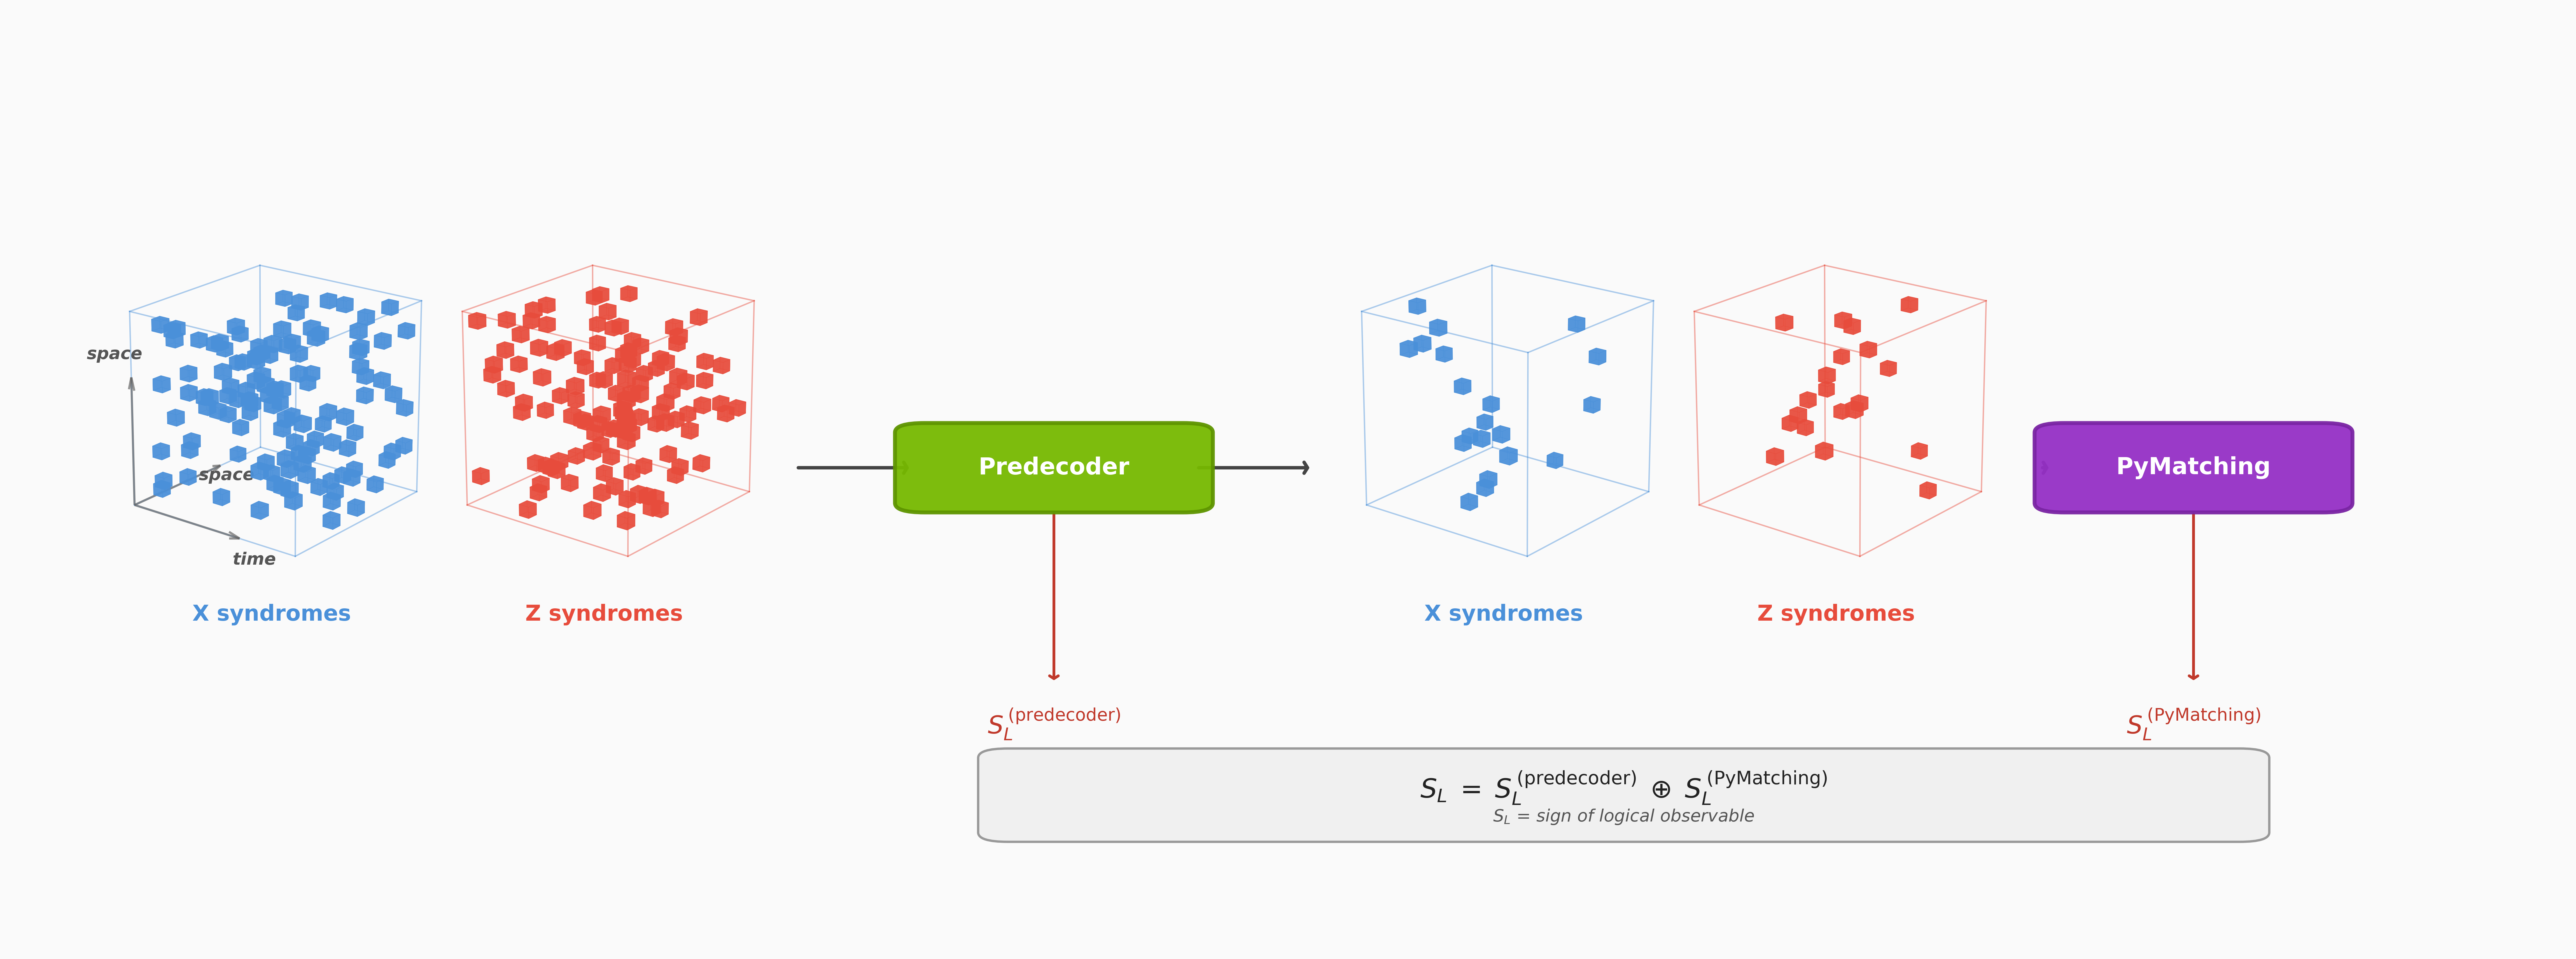

In the above image, the large blocks are the syndrome volumes where the height and depth are the spatial dimensions of the surface code and the width is the temporal dimension. Small colored blocks are flagged syndromes.

At first it may seem that adding a step will slow things down, but in fact, this allows faster overall decoding compared to PyMatching alone.  In many cases, the decoding time *and* the accuracy are improved using the predecoder approach! 


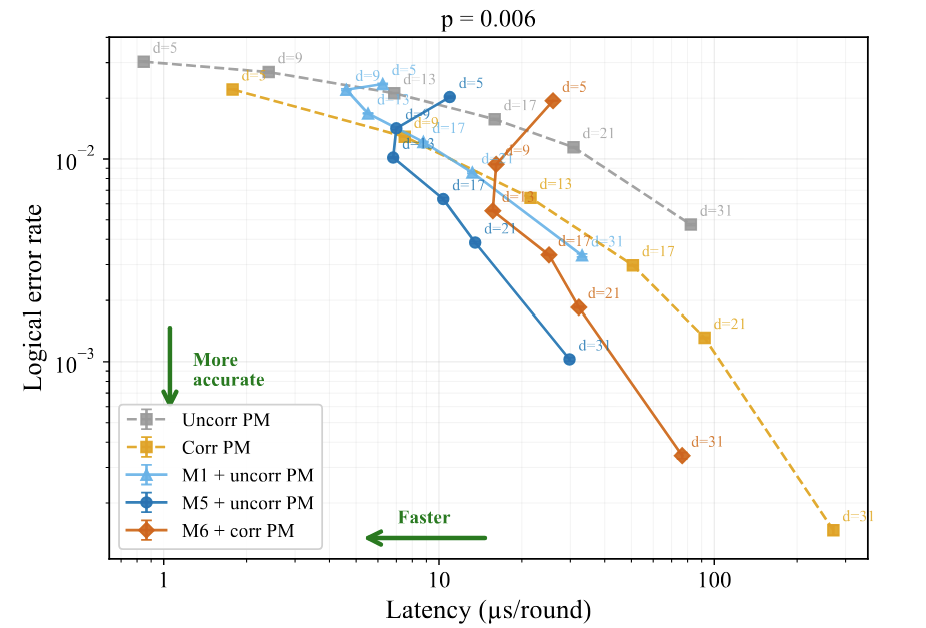


In the figure above taken from the [NVIDIA Ising pre-decoder whitepaper](https://research.nvidia.com/publication/2026-04_fast-ai-based-pre-decoders-surface-codes), with the model computed using a batch size of 1 on a GB300 with FP8 precision and PyMatching computed on a Grace Neoverse-V2 CPU, the grey and yellow lines correspond to PyMatching with increasing code distances. The blue and red lines are different combinations of the NVIDIA Ising pre-decoder and PyMatching.  Notice, that many of the data points (with fixed distance) are below and left of the PyMatching points, meaning that we can produce lower logical error rates with less latency compared to PyMatching.  Generally, PyMatching is more accurate at high distances, but the pre-decoder workflow can run much faster at the cost of a slightly elevated logical error rate (LER).  Even in this case, the pre-decoder workflow provides additional freedom when balancing tradeoffs of accuracy and speed.

### What you will learn in this tutorial

The rest of this tutorial walks through the key workflows for using the Ising decoder:

1. **Quick Start** — Run the full NVIDIA Ising pre-decoder pipeline end-to-end and compare to PyMatching.
2. **Training** — Train your own NVIDIA Ising pre-decoder from scratch with on-the-fly data generation and learn how to set key hyperparameters.
3. **Optimizing Inference** — Improve inference performance using ONNX export, TensorRT FP16, and FP8 quantization for real-time deployment.


The full documentation for the Ising decoder can be found [here](https://github.com/NVIDIA/Ising-Decoding), along with the [whitepaper](https://research.nvidia.com/publication/2026-04_fast-ai-based-pre-decoders-surface-codes) that explains the models in more detail.

### Setup

This tutorial can be found in the `cookbook/` directory of the `Ising-Decoding` repository.

**Prerequisites:**
- **NVIDIA GPU** with CUDA drivers installed (`nvidia-smi` must be on your PATH)
- **Python 3.11, 3.12, or 3.13**

The cell below will:
1. Locate the repository root and add the predecoder source code to the Python path
2. Detect the CUDA version from your GPU driver and install the matching PyTorch build
3. Install all training dependencies (which are a superset of inference dependencies), including cuQuantum for GPU-accelerated data generation, ONNX tooling for the inference optimization sections, and all other required packages
4. Authenticate with Hugging Face to download pre-trained model weights (the model is access-controlled). **Paste your token into the `HF_TOKEN` variable** in the cell below (get one at https://huggingface.co/settings/tokens)

**TensorRT** (used in the FP16 engine and FP8 quantization sections) is installed automatically with the correct CUDA version.

**Note:** If you have already run the setup cell once and all packages are installed, you can skip it on subsequent runs — only the imports cell that follows is needed.

In [ ]:
import subprocess, sys, os, re, shutil

NOTEBOOK_DIR = os.path.abspath('')
PREDECODER_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR,'..'))
sys.path.insert(0, os.path.join(PREDECODER_ROOT, 'code'))

print(f'PREDECODER_ROOT: {PREDECODER_ROOT}')
assert os.path.isdir(os.path.join(PREDECODER_ROOT, 'code')), (
    f"Cannot find predecoder source code at {PREDECODER_ROOT}/code. "
    f"This notebook must live at <repo_root>/tutorials/predecoder_tutorial/."
)

assert shutil.which('nvidia-smi'), 'nvidia-smi not found — this tutorial requires an NVIDIA GPU.'

nvsmi_output = subprocess.check_output(['nvidia-smi'], text=True)
cuda_match = re.search(r'CUDA Version:\s+([\d.]+)', nvsmi_output)
assert cuda_match, 'Could not detect CUDA version from nvidia-smi output.'
cuda_ver = cuda_match.group(1)
cuda_major = cuda_ver.split('.')[0]
print(f'CUDA {cuda_ver} detected (major: {cuda_major})')

def _pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *args])

gpu_info = subprocess.check_output(
    ['nvidia-smi', '--query-gpu=name,compute_cap', '--format=csv,noheader'], text=True
).strip().split('\n')[0]
gpu_name, gpu_cc = [s.strip() for s in gpu_info.split(',')]
gpu_cc_major = int(gpu_cc.split('.')[0])
gpu_cc_minor = int(gpu_cc.split('.')[1])
gpu_supports_fp8 = (gpu_cc_major > 8) or (gpu_cc_major == 8 and gpu_cc_minor >= 9)
print(f'GPU: {gpu_name} (compute capability {gpu_cc}, FP8: {"yes" if gpu_supports_fp8 else "no"})')

print('Environment OK.')


In [ ]:
_pip('--upgrade', 'pip', 'setuptools<82', 'wheel')

torch_cuda_tag = {'12': 'cu128', '13': 'cu130'}[cuda_major]
print(f'Installing PyTorch (wheel index: {torch_cuda_tag})...')
_pip('torch', '--index-url', f'https://download.pytorch.org/whl/{torch_cuda_tag}',
     '--extra-index-url', 'https://pypi.org/simple')

import torch
assert torch.cuda.is_available(), 'PyTorch installed but CUDA is not available.'
print(f'PyTorch {torch.__version__}, CUDA {torch.version.cuda}, '
      f'GPU: {torch.cuda.get_device_name(0)}')

In [ ]:
train_req = os.path.join(PREDECODER_ROOT, 'code', f'requirements_public_train-cu{cuda_major}.txt')
assert os.path.exists(train_req), (
    f"No training requirements for CUDA {cuda_major}: {train_req}\n"
    f"Available: requirements_public_train-cu12.txt, requirements_public_train-cu13.txt"
)
print(f'Installing predecoder dependencies from: {os.path.basename(train_req)}')
print(f'  (this includes: stim, pymatching, cuquantum, onnx tooling, and more)')
_pip('-r', train_req, 'huggingface_hub')

trt_pkg = f'tensorrt-cu{cuda_major}'
print(f'Installing TensorRT ({trt_pkg}) for ONNX optimization sections...')
_pip(trt_pkg)

print('All dependencies installed.')

In [ ]:
# Paste your Hugging Face token below (get one at https://huggingface.co/settings/tokens).
HF_TOKEN = ""  # <-- paste your token here, e.g. "hf_abc123..."

import huggingface_hub
if HF_TOKEN:
    huggingface_hub.login(token=HF_TOKEN)
    print('Logged in to Hugging Face.')
elif huggingface_hub.get_token():
    print('Using previously cached Hugging Face token.')
else:
    raise RuntimeError(
        'No Hugging Face token found. Paste your token into the HF_TOKEN variable above.\n'
        'Get one at: https://huggingface.co/settings/tokens'
    )

In [ ]:
import torch
import numpy as np
import pymatching
import time
from types import SimpleNamespace

from qec.noise_model import NoiseModel
from qec.surface_code.memory_circuit import MemoryCircuit
from model.registry import get_model_spec
from model.factory import ModelFactory
from evaluation.logical_error_rate import PreDecoderMemoryEvalModule, _build_stab_maps

---
## Quick Start

The fastest path to running the pre-decoder is shown below. This code cell generates $d$=9 surface code syndrome data directly using the repo's `MemoryCircuit` and STIM, loads the pre-trained model from [Hugging Face](https://huggingface.co/nvidia/ising_decoder_surface_code_1_fast), and runs the full decode pipeline. Note, we are using the model optimized for speed, but a second pretrained model targeting accuracy is available [here](https://huggingface.co/nvidia/ising_decoder_surface_code_1_accurate).

The workflow has four primary steps:

- **Syndrome data generation** — A noisy surface code circuit is simulated using STIM. Each shot produces a set of detector bits (syndrome differences across rounds) and an observable bit (whether a logical error occurred). This is what a real QPU would send to the classical decoder.
- **Pre-trained model** — A 3D convolutional neural network trained to recognize local, easily identifiable error patterns directly from syndrome data. It processes thousands of shots in parallel on GPU and returns a set of corrections along with a reduced residual syndrome.
- **Pre-decoder inference pipeline** — The model is wrapped with preprocessing (mapping flat syndrome bits onto a spatial grid) and postprocessing (applying predicted corrections to reduce the syndrome). The output is a partial logical correction and a much sparser syndrome for PyMatching to handle.
- **PyMatching on residuals** — The industry-standard MWPM decoder finishes the job on the reduced syndrome. Its result is XOR'd with the pre-decoder's partial correction to produce the final logical error prediction.

**Data format:** The pre-decoder takes a flat array of detector bits, obtained from a QPU or via simulation in the case of this example. Internally, these bits are reshaped into a 4-channel 3D grid of shape `(batch, 4, rounds, distance, distance)` before being passed to the CNN. The four channels encode X and Z syndrome values and the surface code boundary geometry. For full details on the data format and model architecture, see [the paper](https://research.nvidia.com/publication/2026-04_fast-ai-based-pre-decoders-surface-codes).


Run the code below to see how the performance of PyMatching, the Ising decoder, and the combination of both compare.


In [ ]:
# ── 1. Generate syndrome data ────────────────────────────────────────────────
# These are the key QEC parameters for a surface code memory experiment.
# distance=9 means a 9x9 grid of data qubits (81 qubits + 80 ancilla).
# n_rounds=9 is the number of syndrome measurement cycles (standard: match distance).
# basis="X" means we protect the X-type logical qubit (alternatively "Z").
# code_rotation="XV" is the internal label for surface code orientation O1.
distance, n_rounds, basis, code_rotation, num_samples = 9, 9, "X", "XV", 5000

# Build a 25-parameter depolarizing noise model from a single error rate p=0.005.
# from_single_p() distributes p across all error channels using standard ratios:
#   prep/meas errors:     2p/3  (~0.0033)
#   idle during CNOT:     p/3   (~0.0017)
#   idle during SPAM:     2p/3  (~0.0033)
#   two-qubit CNOT:       p/15  (~0.00033) per Pauli pair

noise = NoiseModel.from_single_p(0.005)
p_max = noise.get_max_probability()  # largest value across all 25 params (~2p/3)

# Build the full noisy surface code circuit using Stim.
# The scalar error args (idle_error, sqgate_error, etc.) are placeholder values
# required by the constructor — the actual error channels are driven by noise_model.
# add_boundary_detectors=True adds virtual detectors at the start/end of the circuit,
# which improves decoding accuracy at the temporal boundaries of the experiment.

circ = MemoryCircuit(
    distance=distance, n_rounds=n_rounds, basis=basis, code_rotation=code_rotation,
    idle_error=p_max, sqgate_error=p_max, tqgate_error=p_max,
    spam_error=(2/3)*p_max, noise_model=noise, add_boundary_detectors=True,
)
circ.set_error_rates()

# Sample the circuit: each row of `shots` is one full experiment run (all measurements).
shots       = circ.stim_circuit.compile_sampler().sample(num_samples)

# Convert raw measurement bits into detector outcomes and logical observable flips.
# Detectors are syndrome parities across two consecutive rounds — they fire (=1)
# when consecutive stabilizer measurements disagree, signaling an error.
# Observables are the true logical error bits — what we're trying to predict.

conv        = circ.stim_circuit.compile_m2d_converter()
dets_obs    = conv.convert(measurements=shots, append_observables=True)
num_obs     = circ.stim_circuit.num_observables
detectors   = dets_obs[:, :-num_obs].astype(np.uint8)   # shape: (shots, n_detectors)
observables = dets_obs[:, -num_obs:].astype(np.uint8)   # shape: (shots, n_observables)

# Build the Detector Error Model (DEM): a graph where nodes are detectors and
# edges are the most likely single-error mechanisms connecting them.
# PyMatching uses this graph to find minimum-weight correction paths.

dem = circ.stim_circuit.detector_error_model(
    decompose_errors=True,       # split multi-detector errors into pairs for graph compatibility
    approximate_disjoint_errors=True,  # merge nearly-identical error mechanisms
)


With the syndrome data generated, we now have `detectors` (the parity-check outcomes the decoder will work with) and `observables` (the ground-truth logical errors we want to predict). We also built a Detector Error Model (`dem`) that PyMatching will use later.

Next, we load the pre-trained Ising pre-decoder model from Hugging Face. Model 1 has a receptive field of R=9, which matches our $d$=9 experiment exactly.

In [ ]:
# ── 2. Load pre-trained model ────────────────────────────────────────────────
# Model 1 has receptive field R=9, matching our d=9 experiment.
# The receptive field sets the maximum space-time window the model can see.

model_id = 1
spec     = get_model_spec(model_id)

# Build the model architecture from the registry spec.
# num_filters/kernel_size define the 3D convolutional layers that process the
# syndrome tensor (space x space x time).

model_cfg = SimpleNamespace(
    code="surface", distance=distance, n_rounds=n_rounds,
    model=SimpleNamespace(
        version="predecoder_memory_v1",
        num_filters=list(spec.num_filters), kernel_size=list(spec.kernel_size),
        dropout_p=0.0, activation="gelu", input_channels=4, out_channels=4,
    ),
)
model = ModelFactory.create_model(model_cfg)

# Download weights from HuggingFace (cached after first run).
import logging
logging.getLogger("httpx").setLevel(logging.WARNING)
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file

model_path = hf_hub_download(
    repo_id="nvidia/ising_decoder_surface_code_1_fast",
    filename="ising_decoder_surface_code_1_fast_r9_v1.0.77_fp16.safetensors",
    token=HF_TOKEN or True,
)
sd = load_file(model_path, device="cpu")
sd = {(k[7:] if k.startswith("module.") else k): v.float() for k, v in sd.items()}
model.load_state_dict(sd)
model.eval()

The model printed above is just the neural network — it knows how to process data, but it expects a very specific input format (a 4-channel 3D tensor shaped to the surface code lattice), not the flat array of detector bits we generated earlier. The next cell wraps the model inside `PreDecoderMemoryEvalModule`, which handles the format conversion automatically: flat detector bits go in, and a partial logical correction plus a simplified syndrome for PyMatching come out.

In [ ]:
# ── 3. Build inference pipeline ──────────────────────────────────────────────
# Move model to GPU if available; CPU fallback works but will be slow.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = model.to(device)

# Build stabilizer maps: spatial lookup tables that tell the model which detectors
# correspond to which physical qubit locations on the surface code lattice.
maps = _build_stab_maps(distance, code_rotation)

# PreDecoderMemoryEvalModule wraps the model with the pre/post-processing needed
# for inference: it accepts raw detector arrays and returns:
#   out[:, 0]  — predicted logical correction (0 or 1 per shot)
#   out[:, 1:] — residual detectors after pre-decoding (passed to PyMatching)
eval_cfg = SimpleNamespace(
    distance=distance,
    test=SimpleNamespace(meas_basis_test=basis, th_data=0.0, th_syn=0.0,
                         sampling_mode="threshold", temperature=1.0,
                         temperature_data=None, temperature_syn=None, n_rounds=n_rounds),
    data=SimpleNamespace(code_rotation=code_rotation),
    enable_fp16=False,
)
pipeline = PreDecoderMemoryEvalModule(model, eval_cfg, maps, device).to(device)
pipeline.eval();

The `pipeline` object now encapsulates the entire pre-decoder workflow in a single callable: give it a batch of raw detector bits and it returns a two-part result — a predicted logical correction (column 0) and a set of residual syndromes (remaining columns) that have been simplified by the neural network. Those residual syndromes are what we will pass to PyMatching as a second decoding step.

Everything is ready. We now compare four decoding strategies side by side:

1. **Undecoded** — no correction at all (the raw logical error rate)
2. **PyMatching only** — the standard MWPM decoder applied to the full syndrome
3. **Pre-decoder alone** — just the neural network's partial correction, no follow-up
4. **Pre-decoder + PyMatching** — the full pipeline: the model reduces the syndrome, then PyMatching finishes the job on the sparser residual. The final correction is the XOR of both predictions.

A single warmup pass runs first so that `torch.compile` JIT-compiles the model for this batch shape before we start timing.

In [ ]:
# ── 4. Run all four decoding strategies ─────────────────────────────────────
# Build the PyMatching decoder from the DEM graph — this is the classical baseline.

matcher  = pymatching.Matching.from_detector_error_model(dem)
obs_flat = observables.flatten()

# Warmup pass: torch.compile JIT-compiles the model on first call for this batch
# shape/dtype. We discard these timings — subsequent calls reflect true latency.

with torch.no_grad():
    _ = pipeline(torch.from_numpy(detectors).to(torch.uint8).to(device))
_ = matcher.decode_batch(detectors)



# Strategy 1 — Undecoded (baseline: what LER looks like with no correction at all)

undecoded_ler = obs_flat.mean()



# Strategy 2 — PyMatching only (standard MWPM decoder, the classical state of the art)

t0       = time.perf_counter()
pm_pred  = np.asarray(matcher.decode_batch(detectors), dtype=np.uint8).reshape(-1, num_obs).flatten()
t_pm     = time.perf_counter() - t0
pm_ler   = (pm_pred != obs_flat).mean()



# Strategy 3 — Pre-decoder alone (neural network output, no follow-up matching)
# This shows what the model achieves without a global decoder — useful for
# understanding the pre-decoder's contribution in isolation.

dets_t = torch.from_numpy(detectors).to(torch.uint8).to(device)
t0 = time.perf_counter()
with torch.no_grad():
    out = pipeline(dets_t)
t_pd     = time.perf_counter() - t0
pre_L    = out[:, 0].cpu().numpy()   # model's logical correction prediction
res_dets = out[:, 1:].cpu().numpy().astype(np.uint8)  # residual syndromes for PyMatching
pd_ler   = (pre_L.astype(int) != obs_flat.astype(int)).mean()



# Strategy 4 — Pre-decoder + PyMatching (the full pipeline)
# The model first simplifies the syndrome pattern (reducing syndrome density),
# then PyMatching decodes the cleaner residual syndromes. The final logical
# correction is XOR of the two predictions (mod 2 addition of Pauli corrections).

t0       = time.perf_counter()
pm_res   = np.asarray(matcher.decode_batch(res_dets), dtype=np.uint8).reshape(-1, num_obs).flatten()
t_pm_res = time.perf_counter() - t0
combo_L  = (pre_L.astype(int) + pm_res.astype(int)) % 2  # combine both corrections
combo_ler = (combo_L != obs_flat).mean()
t_combo  = t_pd + t_pm_res  # total wall time for the combined pipeline



# ── 5. Results ───────────────────────────────────────────────────────────────
print(f"  {'Strategy':<30}  {'LER':>8}  {'Time (ms)':>10}  {'µs/shot':>8}")
print(f"  {'-'*30}  {'-'*8}  {'-'*10}  {'-'*8}")
print(f"  {'Undecoded':<30}  {undecoded_ler:>8.5f}  {'—':>10}  {'—':>8}")
print(f"  {'PyMatching only':<30}  {pm_ler:>8.5f}  {t_pm*1e3:>9.1f}ms  {t_pm*1e6/num_samples:>7.1f}µs")
print(f"  {'Pre-decoder alone':<30}  {pd_ler:>8.5f}  {t_pd*1e3:>9.1f}ms  {t_pd*1e6/num_samples:>7.1f}µs")
print(f"  {'Pre-decoder + PyMatching':<30}  {combo_ler:>8.5f}  {t_combo*1e3:>9.1f}ms  {t_combo*1e6/num_samples:>7.1f}µs")

Notice that the LER of the NVIDIA Ising pre-decoder + PyMatching combination is nearly identical to PyMatching alone in this case, but the overall and per-shot decoding time is much smaller for the pre-decoder + PyMatching approach.

An important caveat: the workflow above shows decode time for a batch of 5,000 syndromes. If you run the same code with a batch size of 1, as you would in a real-time QEC application, the pre-decoder + PyMatching approach is much slower than PyMatching alone, due to the significant overhead of launching a GPU kernel. Batched decoding amortizes that overhead across all 5,000 syndrome rounds at once. 

This behavior is expected at small scale and is consistent with the results from the [paper](https://research.nvidia.com/publication/2026-04_fast-ai-based-pre-decoders-surface-codes). Compare the d=9 point for the light-blue line (pre-decoder + PyMatching) and the grey line (PyMatching only).

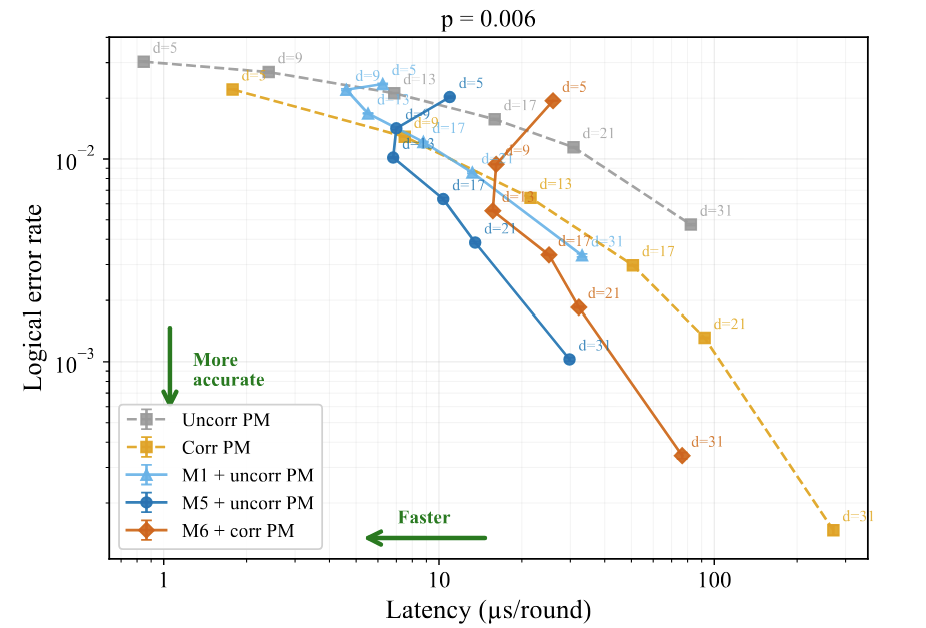

To reach a regime where the kernel-launch overhead is worth the tradeoff, we need a combination of:

1. A higher-distance surface code
2. A more complex noise model (i.e., harder-to-decode syndrome patterns)
3. Optimizations for low-latency model inference

In the next section, you will learn how to train your own model on higher-distance surface codes with much more complex noise patterns, using on-the-fly GPU-accelerated syndrome generation with cuStabilizer. After that, you will learn how to optimize model inference for the best possible real-time deployment performance on your specific GPU. Together, these sections will equip you to study regimes where the NVIDIA Ising pre-decoder + PyMatching approach significantly outperforms PyMatching alone.

---
## Training your own Pre-decoder Model

The pre-trained models ship with this repo, but there are several reasons you might want to train your own:

- **Custom noise model**: The pre-trained models were trained on a specific noise profile. Real quantum hardware has different error characteristics and you may want to see how the model handles a custom noise profile.
- **Different code distances**: Pre-trained models are available for specific distances. Training lets you target any distance within the model's receptive field.
- **Different noise regimes**: Physical error rates vary by platform. A model trained at p ≈ 0.005 may not be optimal for p ≈ 0.001 or p ≈ 0.006.
- **Architecture exploration**: The 5 public models vary in depth and width. Training lets you experiment with the tradeoff between model size (latency) and correction quality (LER improvement).

The following sections will walk you through the process for training your own model.

### Model Variants

Five model variants are available, trading off model size against correction quality. The **receptive field (RF)** determines the spatial and temporal window the model can see: a model with RF = 9 requires `distance ≥ 9` and `n_rounds ≥ 9`. Larger RF models can correct more complex, spatially spread errors but cost more compute per shot.

Run the code below to see the model specs for the 5 included model architectures. The length of the `num_filters` list is the number of layers in the model. Generally, more filters allow the model to detect more complex error patterns. The kernel size prescribes the spatial and temporal window over which features are computed.

In [ ]:

print(f"{'Model':<8} {'num_filters':<30} {'kernel_size':<24} {'RF size':<10} {'num_params':>12}")
print("-" * 86)
for mid in range(1, 6):
    spec = get_model_spec(mid)
    cfg = SimpleNamespace(
        code="surface", distance=9, n_rounds=9,
        model=SimpleNamespace(
            version="predecoder_memory_v1",
            num_filters=list(spec.num_filters),
            kernel_size=list(spec.kernel_size),
            dropout_p=0.0, activation="gelu",
            input_channels=4, out_channels=4,
        ),
    )
    m = ModelFactory.create_model(cfg)
    nparams = sum(p.numel() for p in m.parameters())
    print(f"  {mid:<6} {str(spec.num_filters):<30} {str(spec.kernel_size):<24} {spec.receptive_field:<10} {nparams:>12,}")


### On-the-Fly Training Data Generation

A key benefit of the Ising pre-decoder training pipeline is on-the-fly generation of syndrome data during each training epoch. The simulation uses a **25-parameter circuit-level noise model** that independently controls:

- **State preparation errors** (2 params): `p_prep_X`, `p_prep_Z`
- **Measurement errors** (2 params): `p_meas_X`, `p_meas_Z`
- **Idle errors during CNOT layers** (3 params): `p_idle_cnot_X/Y/Z`
- **Idle errors during state-prep/measurement windows** (3 params): `p_idle_spam_X/Y/Z`
- **Two-qubit CNOT gate errors** (15 params): all Pauli pairs `IX, IY, IZ, XI, XX, ... ZZ` (excluding `II`)

This noise model is defined in `conf/config_public.yaml` and can be customized to match real hardware calibration data.

For training, the simulation runs inside `QCDataGeneratorTorch`, which uses GPU accelerated DEM sampling that leverages the [NVIDIA cuStabilizer library](https://docs.nvidia.com/cuda/cuquantum/latest/custabilizer/index.html) within the [NVIDIA cuQuantum library](https://docs.nvidia.com/cuda/cuquantum/latest/index.html) to generate fresh batches of `(trainX, trainY)` tensors on every training step.

GPU-accelerated sampling requires the `cuquantum-python` package (installed automatically by the setup cell above, matched to your CUDA version). Training uses cuStabilizer for on-the-fly data generation and will fail if cuquantum is not installed. Inference uses STIM instead and does not require cuquantum.

For large scale training runs, cuStabilizer provides massive speedups in data generation. 


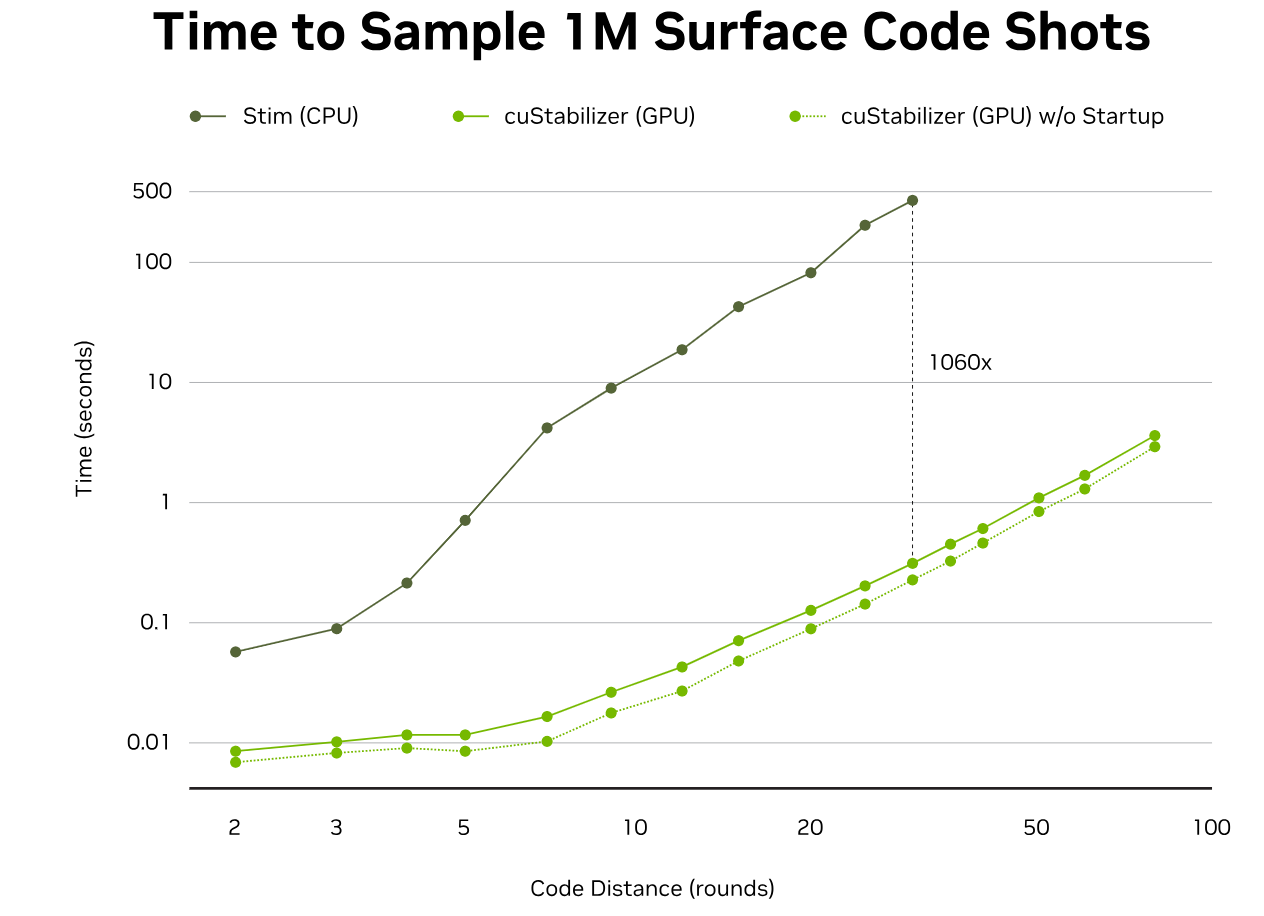


For example, in the above figure, cuStabilizer provides a 1060x speedup over STIM for sampling 1 Million shots from a distance 30 surface code on an NVIDIA DGX B200 GPU.


### Training Configuration

Training is controlled by a single user-facing file: `conf/config_public.yaml`. It exposes the QEC problem variables.

Here are the main settings for your `config_public.yaml`:

| Parameter | What it controls |
|---|---|
| `model_id` | Which model architecture to use (1–5). Each has a fixed **receptive field R** — the maximum distance/rounds it can handle. Models 1 & 2: R=9, Model 3: R=17, Models 4 & 5: R=13 |
| `distance` | Surface code distance for **evaluation** (Training always runs at distance=R) |
| `n_rounds` | Number of syndrome measurement rounds for **evaluation** |
| `workflow.task` | `train` to train a new model, `inference` to evaluate a saved model |
| `data.code_rotation` | Surface code orientation: `O1`, `O2`, `O3`, or `O4` (different logical operator placements) |
| `data.noise_model` | The 25-parameter circuit-level noise model: state prep errors (`p_prep_X/Z`), measurement errors (`p_meas_X/Z`), idle errors during CNOT layers (`p_idle_cnot_X/Y/Z`) and SPAM windows (`p_idle_spam_X/Y/Z`), and all 15 two-qubit CNOT Pauli error rates (`p_cnot_AB`) |


The cell below prints the full default `config_public.yaml` file.


In [ ]:
# === conf/config_public.yaml (what users edit) ===
config_path = os.path.join(PREDECODER_ROOT, "conf", "config_public.yaml")
with open(config_path) as f:
    print(f.read())


`config_validator.py` holds the hidden training hyperparameters: optimizer settings, batch schedule, EMA, early stopping, and more. These are intentionally not in the public config to prevent misconfiguration.

You do not need to touch this file for a standard run. However, some parameters can be overridden at runtime via **environment variables**, without editing any file:

| Environment Variable | Config Parameter | Default | Description |
|---|---|---|---|
| `PREDECODER_TRAIN_SAMPLES` | `train.num_samples` | 67,108,864 | Total training shots generated per epoch (divided into batches based on batch size and GPU count). Default is the production base for 8 GPUs, auto-scaled proportionally to GPU count (e.g. 8,388,608 on 1 GPU). Env var override bypasses scaling |
| `PREDECODER_TRAIN_EPOCHS` | `train.epochs` | 100 | Total number of training epochs |
| `PREDECODER_VAL_SAMPLES` | `val.num_samples` | 65,536 | Total validation shots evaluated at the end of each epoch. Split evenly across GPUs |
| `PREDECODER_TEST_SAMPLES` | `test.num_samples` | 262,144 | Total shots for final LER/SDR evaluation after training. Split evenly across GPUs |
| `PREDECODER_LR_MILESTONES` | `lr_scheduler.milestones` | `0.25,0.5,1.0` | Comma-separated fractions of total training steps. At each milestone the learning rate is multiplied by gamma=0.7. With the defaults, LR drops at 25%, 50%, and 100% of training |
| `PREDECODER_SKIP_NOISE_UPSCALING` | *(env var only)* | `0` | When `0` (default), training noise is automatically scaled up toward the surface code threshold (~0.006) to improve generalization. Set `1` to train with your exact noise model values |
| `PREDECODER_TORCH_COMPILE` | `torch_compile` | `1` | Enables `torch.compile` for the model. Set `0` to disable (useful if training segfaults on startup) |
| `PREDECODER_TORCH_COMPILE_MODE` | `torch_compile_mode` | `default` | `torch.compile` backend mode. Options: `default`, `reduce-overhead`, `max-autotune` |
| `PREDECODER_BASE_OUTPUT_DIR` | *(env var only)* | `outputs/` | Root directory for all run output: checkpoints, TensorBoard logs, Hydra config snapshots |

Parameters **not** accessible via environment variable — such as optimizer internals (`weight_decay`, `beta2`), EMA decay, batch schedule shape, and model architecture can only be changed by editing `apply_public_defaults_and_model()` in `config_validator.py` directly.


### Running Training from the CLI

All training is launched through a single script that reads `conf/config_public.yaml` and applies the hidden defaults from `config_validator.py` automatically.

#### Default training run

All CLI commands below assume you are in the repository root directory (`Ising-Decoding/`).

```bash
bash code/scripts/local_run.sh
```

This trains Model 1 (R=9) at d=9, n_rounds=9 using the default noise model (p≈0.003), with all hidden defaults: Lion optimizer, LR warmup/decay, EMA, and noise upscaling. Output is written to `outputs/test1/`.

---

#### Full reference: everything you can change at the command line

**Shell variables** — control the run itself (prepend before `bash code/scripts/local_run.sh`):

| Variable | What it does | Example |
|---|---|---|
| `EXPERIMENT_NAME` | Names the output folder under `outputs/` — change this when you change config so runs don't mix | `EXPERIMENT_NAME=my_d9_run` |
| `WORKFLOW` | `train` to train, `inference` to evaluate a saved model | `WORKFLOW=inference` |
| `GPUS` | Number of GPUs (uses PyTorch DDP; each GPU gets its own data generator) | `GPUS=4` |
| `CUDA_VISIBLE_DEVICES` | Which physical GPUs to use | `CUDA_VISIBLE_DEVICES=0,1` |
| `FRESH_START` | Set `1` to ignore any existing checkpoint and restart from scratch | `FRESH_START=1` |
| `CONFIG_NAME` | Which config file to load from `conf/` (omit `.yaml`) | `CONFIG_NAME=config_local_test` |

**Environment variables** — override `config_validator.py` hidden defaults at runtime (see the table in the previous section for defaults and detailed descriptions). Prepend these before `bash code/scripts/local_run.sh`:

**Hydra overrides** — override any `config_public.yaml` value inline without editing the file (appended after `local_run.sh`):

| Override | What it does | Example |
|---|---|---|
| `model_id=N` | Select model architecture 1–5 | `model_id=4` |
| `distance=N` | Evaluation distance (training always uses R) | `distance=13` |
| `n_rounds=N` | Evaluation rounds | `n_rounds=13` |
| `data.code_rotation=ON` | Code orientation O1–O4 | `data.code_rotation=O2` |
| `optimizer.lr=X` | Override the model-default learning rate | `optimizer.lr=0.0002` |
| `data.skip_noise_upscaling=true` | Disable noise auto-scaling inline | `data.skip_noise_upscaling=true` |
| `data.noise_model.p_prep_X=X` | Override any individual noise parameter | `data.noise_model.p_prep_X=0.004` |

---

Below are a few example runs you might do and the associated variables to set.

#### Example 1: quick smoke test on 1 GPU

```bash
# Separate output folder, small dataset, 3 epochs, fewer eval shots
EXPERIMENT_NAME=smoke_test \
FRESH_START=1 \
PREDECODER_TRAIN_SAMPLES=65536 \
PREDECODER_TRAIN_EPOCHS=3 \
PREDECODER_TEST_SAMPLES=8192 \
GPUS=1 \
bash code/scripts/local_run.sh
```

#### Example 2: full d=13 run on 8 GPUs with hardware noise

```bash
# 8 GPUs, Model 4 (R=13), hardware-calibrated noise (no auto-scaling)
EXPERIMENT_NAME=d13_hardware_noise \
GPUS=8 \
PREDECODER_SKIP_NOISE_UPSCALING=1 \
bash code/scripts/local_run.sh \
    model_id=4 \
    distance=13 \
    n_rounds=13 \
    data.code_rotation=O1 \
    data.noise_model.p_prep_X=0.001 \
    data.noise_model.p_prep_Z=0.001 \
    data.noise_model.p_meas_X=0.003 \
    data.noise_model.p_meas_Z=0.003
```

#### Example 3: inference on a saved model

```bash
# Must use the same EXPERIMENT_NAME as the training run
EXPERIMENT_NAME=d13_hardware_noise \
WORKFLOW=inference \
bash code/scripts/local_run.sh \
    model_id=4 \
    distance=13 \
    n_rounds=13
```


---
## Optimizing Model Inference

When using the predecoder in a realtime setting, it becomes crucial to minimize the inference time for the model to ensure the decoder has sufficient throughput and the reaction time is as short as possible. There are optimizations which can be used to improve the inference performance of the predecoder model from the AI side of the equation. Each is walked through below.

1. **ONNX Export**: convert the PyTorch pipeline to a portable, framework-independent graph
2. **TensorRT Engine (FP16)**: compile the ONNX graph into a GPU-optimized engine with FP16 precision
3. **FP8 Quantization + TensorRT**: further reduce precision to FP8 for maximum throughput on supported GPUs

The figure below demonstrates why such optimizations are so important for realtime deployment. It shows the speedups achieved for model 1 at three different code distances relative to a FP16 PyTorch run after optimization with TensorRT(FP16) and then quantization with TensorRT(FP8) on a NVIDIA GB300.

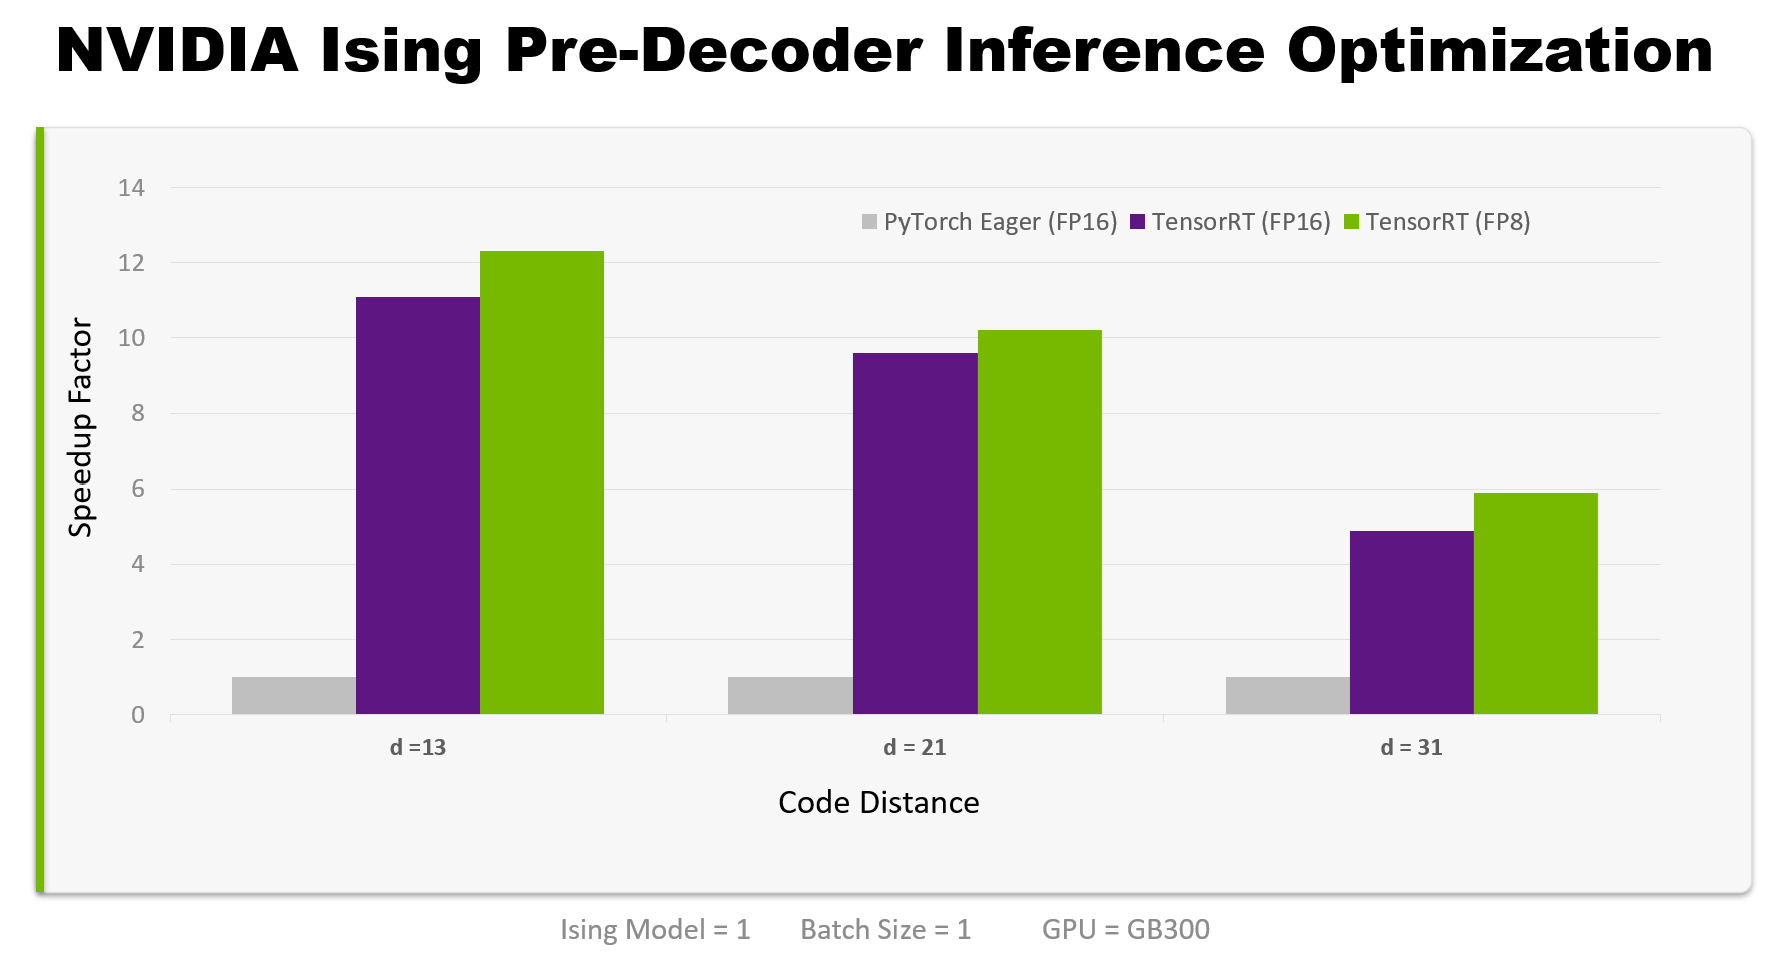

In this case, speedups of around 10x are possible for a batch size of 1. This is just a representative example and not a formal benchmark as model size, code distance, GPU selection, and initial PyTorch optimizations all play a role in the expected speedups. The main point is that these optimizations are easy to perform and always worth doing before your final inference runs. In general, quantization is worth the minimal cost in LER, but you will need to run benchmarks to assess the proper tradeoffs for your experiment.

### Step 1: ONNX Export

[ONNX](https://onnx.ai/) (Open Neural Network Exchange) is a standard format for representing ML models that allows a model trained with a specific framework (e.g. PyTorch) to be converted to a framework-agnostic graph which can be optimized to improve inference performance. Exporting to ONNX gives us:

- **Portability**: the model can be loaded by any ONNX-compatible runtime (TensorRT, ONNX Runtime, etc.)
- **Graph optimization**: constant folding and operator fusion happen at export time
- **Full pipeline in one graph**: we export the entire `PreDecoderMemoryEvalModule`, not just the CNN. This means detector preprocessing, the model forward pass, and residual syndrome computation are all fused into a single ONNX graph.


The input and output signatures of the ONNX graph are:
- **Input**: `dets` — `(B, num_dets)` uint8
- **Output**: `L_and_residual_dets` — `(B, 1 + num_residual_dets)` uint8

B is the batch size and is dynamic, meaning the same ONNX graph can be used to process any batch size without regeneration.

The code below converts our Ising model into an ONNX file. 

**Note:** If you are running CUDA 13 you will see a warning from onnxruntime-gpu about missing CUDA 13 support.  You can safely ignore this warning. ONNX Runtime is used here only as a quick sanity check that the exported graph runs correctly — it automatically falls back to CPU execution. The actual GPU-accelerated inference in this tutorial is handled by TensorRT, which has full CUDA 13 support.



In [ ]:
import logging, warnings
for _name in ["onnxscript", "onnx_ir", "torch.onnx", "torch"]:
    logging.getLogger(_name).setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

# Export the full pipeline to ONNX
onnx_path = "predecoder_memory_d9_T9_X.onnx"

# half = number of X-type (or Z-type) detectors per round for a distance-d surface code
half = (distance**2 - 1) // 2

# Create a small dummy detector batch — torch.onnx.export traces the model
# using this example input to record the full computation graph

example_dets = torch.randint(0, 2, (2, 2 * n_rounds * half), dtype=torch.uint8, device=device)
print(f"Input shape: {example_dets.shape}")

try:
    import onnx

    # Trace the pipeline and serialize the computation graph to an ONNX file.
    # dynamic_axes lets the batch dimension vary at runtime (single shot or batched inference).
    # do_constant_folding=True pre-computes constant sub-expressions at export time.
    
    torch.onnx.export(
        pipeline,
        example_dets,
        onnx_path,
        opset_version=18,
        input_names=["dets"],
        output_names=["L_and_residual_dets"],
        dynamic_axes={
            "dets": {0: "batch"},
            "L_and_residual_dets": {0: "batch"},
        },
        do_constant_folding=True,
    )

    # Verify the exported graph is valid
    model_onnx = onnx.load(onnx_path)
    onnx.checker.check_model(model_onnx)
    onnx_size_mb = os.path.getsize(onnx_path) / (1024 ** 2)
    print(f"Exported and verified: {onnx_path} ({onnx_size_mb:.1f} MB)")

    # Quick inference check with ONNX Runtime
    # Tries CUDA first, falls back to CPU — confirms the graph runs end-to-end
    try:
        import onnxruntime as ort
        providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
        sess = ort.InferenceSession(onnx_path, providers=providers)
        test_input = example_dets.cpu().numpy()
        ort_out = sess.run(None, {"dets": test_input})
        print(f"ONNX Runtime inference OK — output shape: {ort_out[0].shape}")
        active_provider = sess.get_providers()[0]
        print(f"  Running on: {active_provider}")
    except ImportError:
        print("onnxruntime not installed — skipping runtime check.")
        print("Install with: pip install onnxruntime")

except ImportError:
    print("onnx not installed — skipping export.")
    print("Install with: pip install onnx")
    onnx_path = None
except Exception as e:
    print(f"ONNX export failed: {e}")
    onnx_path = None


### Step 2: TensorRT Engine (FP16)

[TensorRT](https://developer.nvidia.com/tensorrt) is NVIDIA's inference compiler which takes an ONNX graph and compiles it into a GPU-architecture-specific engine that accounts for your target data type and batch size range in order to get the most performance out of your GPU. 

Under the hood, TensorRT benchmarks dozens of candidate GPU kernel implementations for each operation in the graph and selects the fastest one for your exact hardware. It then fuses adjacent operations (convolution, normalization, activation) into single GPU kernels, reorganizes tensor memory layouts to maximize cache efficiency, and eliminates the Python interpreter overhead that PyTorch incurs on every call. The result is a binary engine tuned to extract maximum throughput from your specific GPU — the same model weights, the same outputs, but with latency approaching the hardware limit.

The build process:
1. Parse the ONNX model into a TensorRT network
2. Set an **optimization profile** defining the min/optimal/max batch sizes
3. Enable the FP16 flag (tells TensorRT it can use half-precision where beneficial)
4. Build and serialize the engine to a `.engine` file

In [ ]:
# Build a TensorRT engine from the ONNX model (FP16)
engine_path = "predecoder_memory_d9_T9_X_fp16.engine"
batch_size = 1024
in_cols = 2 * n_rounds * half

if onnx_path is None or not os.path.exists(onnx_path):
    print("ONNX model not available — run the ONNX export cell first.")
else:
    try:
        import tensorrt as trt
        print(f"TensorRT version: {trt.__version__}")

        # Create TensorRT logger and builder — entry points for all TRT operations.
        # Store as trt_logger so the FP8 cell can reuse it (avoids a TRT duplicate-logger warning).
        trt_logger = trt.Logger(trt.Logger.WARNING)
        builder = trt.Builder(trt_logger)

        # TRT 10+ removed the EXPLICIT_BATCH flag (always on); TRT 8 needs it.
        trt_major = int(trt.__version__.split(".")[0])
        if trt_major >= 10:
            network = builder.create_network()
        else:
            network = builder.create_network(
                1 << int(trt.NetworkDefinitionCreationFlag.EXPLICIT_BATCH)
            )

        # Parse the ONNX graph into the TensorRT network representation
        parser = trt.OnnxParser(network, trt_logger)
        with open(onnx_path, "rb") as f:
            if not parser.parse(f.read()):
                for err_i in range(parser.num_errors):
                    print(f"  Parse error: {parser.get_error(err_i)}")
                raise RuntimeError("ONNX parse failed")

        # Enable FP16 mode — TensorRT will use half-precision kernels wherever beneficial
        config = builder.create_builder_config()
        config.set_flag(trt.BuilderFlag.FP16)

        # Define the supported batch size range: (min, optimal, max)
        # TensorRT selects the best kernels for the optimal size during compilation
        profile = builder.create_optimization_profile()
        profile.set_shape("dets", (1, in_cols), (batch_size, in_cols), (batch_size, in_cols))
        config.add_optimization_profile(profile)

        # Compile the network into a hardware-specific binary engine and save it
        print(f"Building TensorRT FP16 engine (batch_size={batch_size}) — this may take a minute...")
        serialized = builder.build_serialized_network(network, config)
        with open(engine_path, "wb") as f:
            f.write(serialized)

        engine_size_mb = os.path.getsize(engine_path) / (1024 ** 2)
        print(f"Built: {engine_path} ({engine_size_mb:.1f} MB)")

    except ImportError:
        print("TensorRT not installed — skipping engine build.")
        print("Install with: pip install tensorrt")
    except Exception as e:
        print(f"Engine build failed: {e}")


### Step 3: FP8 Quantization + TensorRT

AI models can be quantized such that their weights are converted to a lower precision.  Often, this provides additional speedup with minimal loss in accuracy. The Ising models are FP16 by default, but TensorRT can quantize to FP8 and achieve further speedups which can run on any GPU with FP8 tensor cores. 

The quantization process is:
1. **Collect calibration data**: representative detector patterns from the test distribution
2. **Quantize the ONNX model**: `nvidia-modelopt` analyzes the calibration data to determine optimal quantization ranges, then inserts QuantizeLinear/DequantizeLinear (QDQ) nodes into the ONNX graph
3. **Build a TensorRT engine**:  TensorRT recognizes the QDQ nodes and fuses them into native FP8 operations

Only the convolution layers are quantized to FP8; the remaining operations (preprocessing, residual computation) stay in FP16 for accuracy.

In [ ]:
import contextlib, io

# FP8 quantization of the ONNX model + TensorRT engine build
fp8_onnx_path = "predecoder_memory_d9_T9_X_fp8.onnx"
fp8_engine_path = "predecoder_memory_d9_T9_X_fp8.engine"

if onnx_path is None or not os.path.exists(onnx_path):
    print("ONNX model not available — run the ONNX export cell first.")
else:
    calib_dets = detectors[:256]
    print(f"Calibration data: {calib_dets.shape} ({calib_dets.shape[0]} samples, dtype: {calib_dets.dtype})")

    try:
        import modelopt.onnx.quantization as mq
        import tensorrt as trt
        print(f"TensorRT version: {trt.__version__}")

        # Quantize convolution layers to FP8 using calibration data to determine
        # optimal scale factors; non-conv ops stay at FP16 for numerical accuracy
        print(f"Quantizing {onnx_path} to FP8 (this may take a moment)...")
        _prev_level = logging.root.manager.disable
        logging.disable(logging.CRITICAL)
        _devnull_fd = os.open(os.devnull, os.O_WRONLY)
        _old_stdout_fd = os.dup(1)
        _old_stderr_fd = os.dup(2)
        _devnull_py = open(os.devnull, "w")
        _old_sys_stdout = sys.stdout
        _old_sys_stderr = sys.stderr
        os.dup2(_devnull_fd, 1)
        os.dup2(_devnull_fd, 2)
        sys.stdout = _devnull_py
        sys.stderr = _devnull_py
        try:
            mq.quantize(
                onnx_path=onnx_path,
                quantize_mode="fp8",
                calibration_data={"dets": calib_dets},
                output_path=fp8_onnx_path,
                op_types_to_quantize=["Conv"],
                high_precision_dtype="fp16",
            )
        finally:
            sys.stdout = _old_sys_stdout
            sys.stderr = _old_sys_stderr
            os.dup2(_old_stdout_fd, 1)
            os.dup2(_old_stderr_fd, 2)
            os.close(_devnull_fd)
            os.close(_old_stdout_fd)
            os.close(_old_stderr_fd)
            _devnull_py.close()
            logging.disable(_prev_level)
        fp8_size_mb = os.path.getsize(fp8_onnx_path) / (1024 ** 2)
        print(f"  Quantized: {fp8_onnx_path} ({fp8_size_mb:.1f} MB)")

        if not gpu_supports_fp8:
            print(f"\n  Skipping FP8 engine build: {gpu_name} (compute capability {gpu_cc}) "
                  f"does not have FP8 tensor cores.")
            print(f"  FP8 requires Ada Lovelace (RTX 4000+, cc 8.9) or Hopper (H100+, cc 9.0).")
            print(f"  The quantized ONNX model ({fp8_onnx_path}) can be built on supported hardware.")
        else:
            _trt_logger = trt_logger if 'trt_logger' in dir() else trt.Logger(trt.Logger.WARNING)
            builder = trt.Builder(_trt_logger)

            trt_major = int(trt.__version__.split(".")[0])
            if trt_major >= 10:
                network = builder.create_network(
                    1 << int(trt.NetworkDefinitionCreationFlag.STRONGLY_TYPED)
                )
            else:
                network = builder.create_network(
                    1 << int(trt.NetworkDefinitionCreationFlag.EXPLICIT_BATCH)
                    | 1 << int(trt.NetworkDefinitionCreationFlag.STRONGLY_TYPED)
                )

            parser = trt.OnnxParser(network, _trt_logger)
            with open(fp8_onnx_path, "rb") as f:
                if not parser.parse(f.read()):
                    raise RuntimeError("ONNX parse failed for FP8 model")

            config = builder.create_builder_config()
            profile = builder.create_optimization_profile()
            profile.set_shape("dets", (1, in_cols), (batch_size, in_cols), (batch_size, in_cols))
            config.add_optimization_profile(profile)

            print(f"Building TensorRT FP8 engine (batch_size={batch_size}) — this may take a minute...")
            serialized = builder.build_serialized_network(network, config)
            with open(fp8_engine_path, "wb") as f:
                f.write(serialized)

            engine_size_mb = os.path.getsize(fp8_engine_path) / (1024 ** 2)
            print(f"Built: {fp8_engine_path} ({engine_size_mb:.1f} MB)")

    except ImportError as e:
        print(f"Required package not available: {e}")
        print("Install with: pip install nvidia-modelopt[onnx] tensorrt")
    except Exception as e:
        print(f"FP8 pipeline failed: {e}")


### Running Optimized Inference from CLI

The full optimization pipeline can also be driven via environment variables from the command line (run from the repository root):

```bash
# PyTorch only (default):
WORKFLOW=inference bash code/scripts/local_run.sh

# ONNX export + TensorRT engine build (FP16):
ONNX_WORKFLOW=2 WORKFLOW=inference bash code/scripts/local_run.sh

# ONNX + FP8 quantization + TensorRT:
ONNX_WORKFLOW=2 QUANT_FORMAT=fp8 WORKFLOW=inference bash code/scripts/local_run.sh

# Load a pre-built engine file:
ONNX_WORKFLOW=3 WORKFLOW=inference bash code/scripts/local_run.sh
```

---
## Learn More

After completing this tutorial, you should have a foundational understanding of how the NVIDIA Ising pre-decoder works and how to get started training your own models.  For more information on the code, explore the [GitHub repo](https://github.com/NVIDIA/Ising-Decoding).  For more details on the model itself and its performance, read the [NVIDIA Ising pre-decoder whitepaper](https://research.nvidia.com/publication/2026-04_fast-ai-based-pre-decoders-surface-codes).

Visit the NVIDIA Ising webpage to learn more about other models in the [NVIDIA Ising family](https://developer.nvidia.com/ising) of open quantum models.